# COPD Severity Prediction
## Using Random Forest on Clinical Data

**Goal:** Predict how severe a patient's COPD is from clinical measurements.

**4 severity levels:**
- MILD
- MODERATE
- SEVERE
- VERY SEVERE

**Pipeline:**
1. Load the data
2. EDA — understand the data
3. Missing values — find and fix
4. Split the data — train / test
5. Train Random Forest
6. Evaluate — confusion matrix, accuracy, precision, recall
7. RAG-ready output

---
## Setup — Install & Import

In [27]:
%pip install pandas numpy matplotlib seaborn scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")

print("All imports OK")

All imports OK


---
## Step 1 — Load the Data

We load the CSV file and take a first look at what's inside.

First, load the file and see its shape.

In [29]:
df = pd.read_csv("../data/dataset__3_.csv")

# Drop unnamed index column if it exists
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("Shape:", df.shape)
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

Shape: (101, 23)
Rows: 101 | Columns: 23


Show the first few rows to see what the data looks like.

In [30]:
df.head()

,ID,AGE,PackHistory,COPDSEVERITY,MWT1,MWT2,MWT1Best,FEV1,FEV1PRED,FVC,...,SGRQ,AGEquartiles,copd,gender,smoking,Diabetes,muscular,hypertension,AtrialFib,IHD
0,58,77,60.0,SEVERE,120.0,120.0,120.0,1.21,36.0,2.40,...,69.55,4,3,1,2,1,0,0,1,0
1,57,79,50.0,MODERATE,165.0,176.0,176.0,1.09,56.0,1.64,...,44.24,4,2,0,2,1,0,0,1,1
2,62,80,11.0,MODERATE,201.0,180.0,201.0,1.52,68.0,2.30,...,44.09,4,2,0,2,1,0,0,1,0
3,145,56,60.0,VERY SEVERE,210.0,210.0,210.0,0.47,14.0,1.14,...,62.04,1,4,1,2,0,0,1,1,0
4,136,65,68.0,SEVERE,204.0,210.0,210.0,1.07,42.0,2.91,...,75.56,1,3,1,2,0,1,1,0,0


Show all column names and their data types.

In [31]:
print("Columns and types:")
print(df.dtypes)

Columns and types:
ID                int64
AGE               int64
PackHistory     float64
COPDSEVERITY        str
MWT1            float64
MWT2            float64
MWT1Best        float64
FEV1            float64
FEV1PRED        float64
FVC             float64
FVCPRED           int64
CAT               int64
HAD             float64
SGRQ            float64
AGEquartiles      int64
copd              int64
gender            int64
smoking           int64
Diabetes          int64
muscular          int64
hypertension      int64
AtrialFib         int64
IHD               int64
dtype: object


The target column is **COPDSEVERITY** — this is what we want to predict.

We also drop the **copd** column because it's just COPDSEVERITY re-encoded as numbers (1=MILD, 4=VERY SEVERE).
If we keep it, the model would cheat by reading the answer directly.

In [32]:
# Drop the leakage column
df = df.drop(columns=["copd"], errors="ignore")

print("Target column values:")
print(df["COPDSEVERITY"].value_counts())

Target column values:
COPDSEVERITY
MODERATE       43
SEVERE         27
MILD           23
VERY SEVERE     8
Name: count, dtype: int64


---
## Step 2 — EDA (Exploratory Data Analysis)

Let's understand the data before building anything.

### 2.1 — How many patients per severity level?

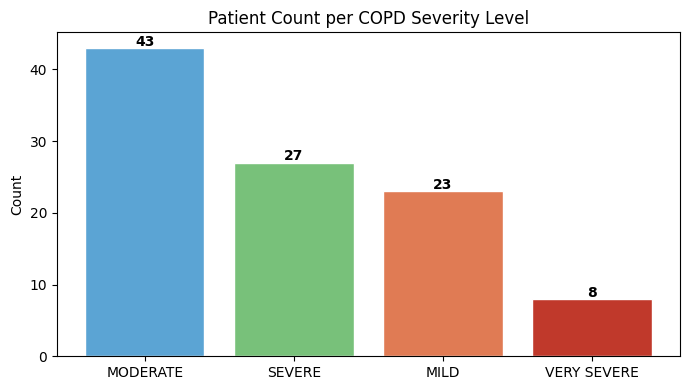

  MODERATE    : 43 patients (42.6%)
  SEVERE      : 27 patients (26.7%)
  MILD        : 23 patients (22.8%)
  VERY SEVERE : 8 patients (7.9%)


In [33]:
counts = df["COPDSEVERITY"].value_counts()
colors = ["#5ba4d4", "#78c17a", "#e07b54", "#c0392b"]

plt.figure(figsize=(7, 4))
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor="white")
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha="center", fontweight="bold")
plt.title("Patient Count per COPD Severity Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

total = counts.sum()
for label, count in counts.items():
    print(f"  {label:<12}: {count} patients ({count/total*100:.1f}%)")

### 2.2 — Basic statistics for all numeric columns

In [34]:
df.describe().round(2)

,ID,AGE,PackHistory,MWT1,MWT2,MWT1Best,FEV1,FEV1PRED,FVC,FVCPRED,...,HAD,SGRQ,AGEquartiles,gender,smoking,Diabetes,muscular,hypertension,AtrialFib,IHD
count,101.00,101.0,101.00,99.00,100.00,100.00,101.00,101.00,101.00,101.00,...,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.0,101.00
mean,91.41,70.1,39.70,385.86,390.28,399.11,1.60,58.53,2.95,86.44,...,11.18,40.19,2.48,0.64,1.84,0.21,0.19,0.12,0.2,0.09
std,51.52,7.9,24.56,104.74,107.75,106.55,0.67,22.29,0.98,21.74,...,8.59,18.24,1.11,0.48,0.37,0.41,0.39,0.33,0.4,0.29
min,1.00,44.0,1.00,120.00,120.00,120.00,0.45,3.29,1.14,27.00,...,0.00,2.00,1.00,0.00,1.00,0.00,0.00,0.00,0.0,0.00
25%,49.00,65.0,20.00,300.00,303.75,303.75,1.10,42.00,2.27,71.00,...,6.00,28.41,1.00,0.00,2.00,0.00,0.00,0.00,0.0,0.00
50%,87.00,71.0,36.00,419.00,399.00,420.00,1.60,60.00,2.77,84.00,...,10.00,38.21,3.00,1.00,2.00,0.00,0.00,0.00,0.0,0.00
75%,143.00,75.0,54.00,460.50,459.00,465.25,1.96,75.00,3.63,103.00,...,15.00,55.23,3.00,1.00,2.00,0.00,0.00,0.00,0.0,0.00
max,169.00,88.0,109.00,688.00,699.00,699.00,3.18,102.00,5.37,132.00,...,56.20,77.44,4.00,1.00,2.00,1.00,1.00,1.00,1.0,1.00


### 2.3 — Age distribution by severity

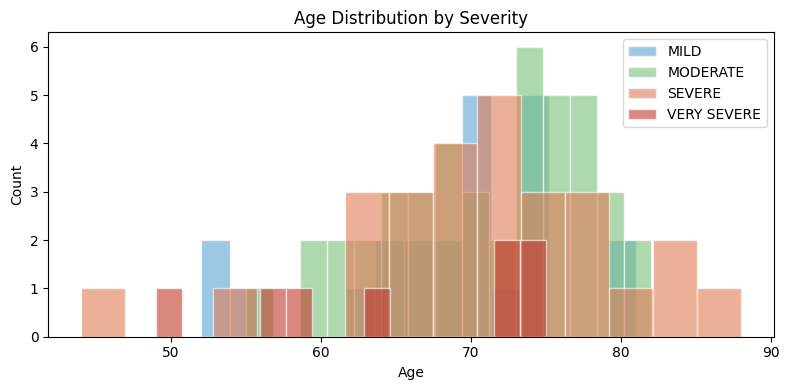

In [35]:
plt.figure(figsize=(8, 4))
for severity, color in zip(["MILD", "MODERATE", "SEVERE", "VERY SEVERE"],
                            ["#5ba4d4", "#78c17a", "#e07b54", "#c0392b"]):
    subset = df[df["COPDSEVERITY"] == severity]["AGE"]
    plt.hist(subset, bins=15, alpha=0.6, label=severity, color=color, edgecolor="white")

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution by Severity")
plt.legend()
plt.tight_layout()
plt.show()

### 2.4 — Correlation heatmap (how features relate to each other)

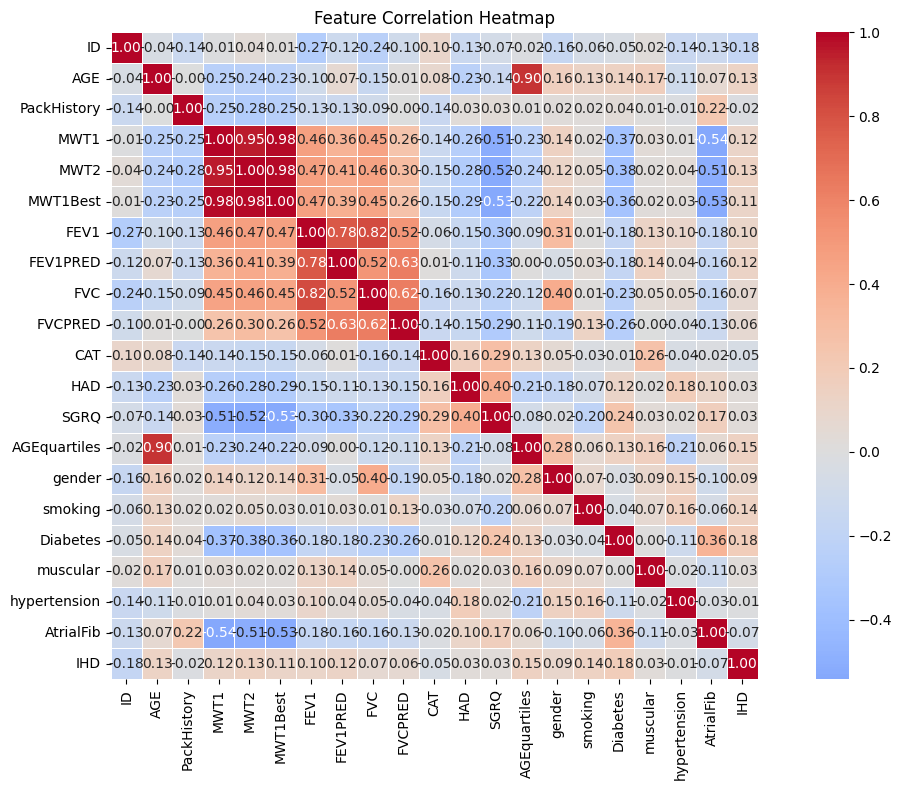

In [36]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### 2.5 — FEV1 by severity (FEV1 is the key lung function measure)

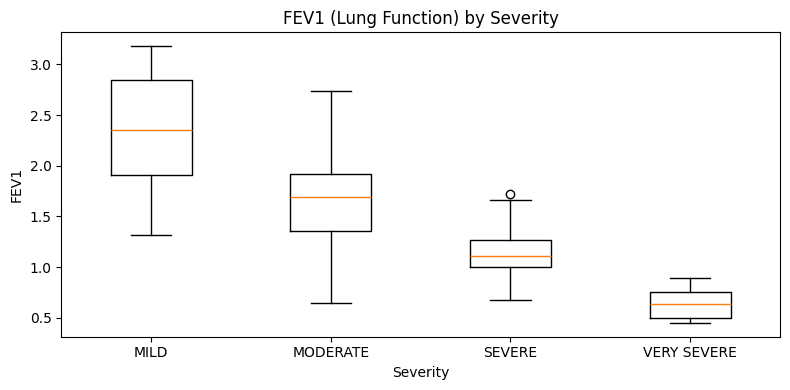

Mean FEV1 per severity:
COPDSEVERITY
MILD           2.37
MODERATE       1.67
SEVERE         1.14
VERY SEVERE    0.64
Name: FEV1, dtype: float64


In [37]:
plt.figure(figsize=(8, 4))
order = ["MILD", "MODERATE", "SEVERE", "VERY SEVERE"]
data_to_plot = [df[df["COPDSEVERITY"] == s]["FEV1"].dropna() for s in order]

plt.boxplot(data_to_plot, labels=order)
plt.title("FEV1 (Lung Function) by Severity")
plt.ylabel("FEV1")
plt.xlabel("Severity")
plt.tight_layout()
plt.show()

print("Mean FEV1 per severity:")
print(df.groupby("COPDSEVERITY")["FEV1"].mean().round(2))

---
## Step 3 — Missing Values

Find any missing values and decide how to handle them.

First, count missing values in every column.

In [38]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found!")
else:
    print("Missing values:")
    for col, count in missing.items():
        pct = count / len(df) * 100
        print(f"  {col:<15}: {count} missing ({pct:.1f}%)")

Missing values:
  MWT1           : 2 missing (2.0%)
  MWT2           : 1 missing (1.0%)
  MWT1Best       : 1 missing (1.0%)


We fill missing values with the **median** of that column.

Why median and not mean? The median is not affected by extreme values (outliers).
If one patient has an unusually high value, the mean would shift — the median stays stable.

In [39]:
# Fill missing numeric values with median
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled '{col}' missing values with median = {median_val:.2f}")

print("\nMissing values after filling:", df.isnull().sum().sum())

Filled 'MWT1' missing values with median = 419.00
Filled 'MWT2' missing values with median = 399.00
Filled 'MWT1Best' missing values with median = 420.00

Missing values after filling: 0


---
## Step 4 — Split the Data

Separate features (X) from the target (y), then split into train and test sets.

Define which columns are features and which is the target.

In [40]:
# These are the features we use to predict severity
FEATURES = [
    "AGE", "PackHistory", "FEV1", "FEV1PRED", "FVC", "FVCPRED",
    "MWT1Best", "CAT", "HAD", "SGRQ",
    "gender", "smoking", "Diabetes", "muscular",
    "hypertension", "AtrialFib", "IHD"
]

TARGET = "COPDSEVERITY"

X = df[FEATURES]
y = df[TARGET]

print("Features shape:", X.shape)
print("Target shape  :", y.shape)
print("\nFeatures used:", FEATURES)

Features shape: (101, 17)
Target shape  : (101,)

Features used: ['AGE', 'PackHistory', 'FEV1', 'FEV1PRED', 'FVC', 'FVCPRED', 'MWT1Best', 'CAT', 'HAD', 'SGRQ', 'gender', 'smoking', 'Diabetes', 'muscular', 'hypertension', 'AtrialFib', 'IHD']


Split into 80% training and 20% testing.

The model **only learns from the training set**. The test set is kept hidden until the end — that's how we get an honest measure of performance.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y    # keep same severity ratio in both splits
)

print("Train size:", len(X_train), "patients")
print("Test size :", len(X_test),  "patients")
print("\nSeverity distribution in train:")
print(y_train.value_counts())
print("\nSeverity distribution in test:")
print(y_test.value_counts())

Train size: 80 patients
Test size : 21 patients

Severity distribution in train:
COPDSEVERITY
MODERATE       34
SEVERE         22
MILD           18
VERY SEVERE     6
Name: count, dtype: int64

Severity distribution in test:
COPDSEVERITY
MODERATE       9
MILD           5
SEVERE         5
VERY SEVERE    2
Name: count, dtype: int64


---
## Step 5 — Train the Random Forest

Random Forest builds many decision trees and combines their votes.
Each tree sees a random subset of the data and features — so they all learn slightly different things.
The final prediction = the majority vote across all trees.

Train the model.

In [42]:
model = RandomForestClassifier(
    n_estimators = 100,    # 100 trees
    max_depth    = None,   # trees grow until pure
    random_state = 42,
)

model.fit(X_train, y_train)

print("Model trained on", len(X_train), "patients")
print("Number of trees:", model.n_estimators)

Model trained on 80 patients
Number of trees: 100


See which features the model found most important.

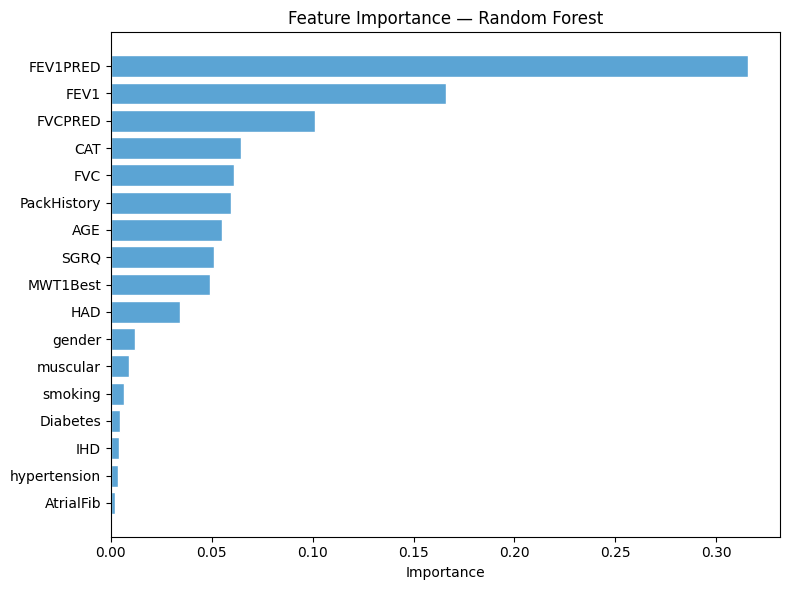

Top 5 most important features:
  FEV1PRED       : 0.3158
  FEV1           : 0.1663
  FVCPRED        : 0.1013
  CAT            : 0.0645
  FVC            : 0.0611


In [43]:
importances = pd.Series(model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
bars = plt.barh(importances.index, importances.values, color="#5ba4d4", edgecolor="white")
plt.xlabel("Importance")
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<15}: {imp:.4f}")

---
## Step 6 — Evaluate the Model

Now we test on the held-out test set and measure performance.

### 6.1 — Make predictions on the test set

In [44]:
y_pred = model.predict(X_test)

print("Sample predictions vs actual:")
for actual, predicted in zip(list(y_test[:8]), list(y_pred[:8])):
    match = "✓" if actual == predicted else "✗"
    print(f"  Actual: {actual:<12}  Predicted: {predicted:<12}  {match}")

Sample predictions vs actual:
  Actual: VERY SEVERE   Predicted: VERY SEVERE   ✓
  Actual: MILD          Predicted: MILD          ✓
  Actual: MODERATE      Predicted: MODERATE      ✓
  Actual: MILD          Predicted: MODERATE      ✗
  Actual: MODERATE      Predicted: MODERATE      ✓
  Actual: SEVERE        Predicted: SEVERE        ✓
  Actual: MODERATE      Predicted: MILD          ✗
  Actual: SEVERE        Predicted: SEVERE        ✓


### 6.2 — Overall accuracy

In [45]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy*100:.1f}%")
print(f"Correct: {int(accuracy * len(y_test))} out of {len(y_test)} patients")

Overall Accuracy: 81.0%
Correct: 17 out of 21 patients


### 6.3 — Confusion matrix

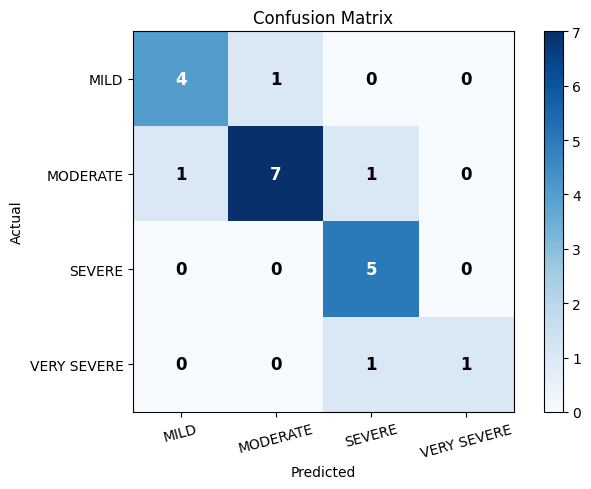

In [46]:
labels = ["MILD", "MODERATE", "SEVERE", "VERY SEVERE"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(4), labels, rotation=15)
plt.yticks(range(4), labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(4):
    for j in range(4):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black",
                 fontweight="bold", fontsize=12)

plt.tight_layout()
plt.show()

### 6.4 — Full classification report (precision, recall, F1 per class)

In [47]:
report = classification_report(y_test, y_pred, labels=labels)
print(report)

              precision    recall  f1-score   support

        MILD       0.80      0.80      0.80         5
    MODERATE       0.88      0.78      0.82         9
      SEVERE       0.71      1.00      0.83         5
 VERY SEVERE       1.00      0.50      0.67         2

    accuracy                           0.81        21
   macro avg       0.85      0.77      0.78        21
weighted avg       0.83      0.81      0.81        21



### 6.5 — Summary metrics

In [48]:
precision = precision_score(y_test, y_pred, average="weighted")
recall    = recall_score(y_test, y_pred, average="weighted")
f1        = f1_score(y_test, y_pred, average="weighted")

print("=" * 40)
print("  MODEL PERFORMANCE SUMMARY")
print("=" * 40)
print(f"  Accuracy  : {accuracy*100:.1f}%")
print(f"  Precision : {precision*100:.1f}%")
print(f"  Recall    : {recall*100:.1f}%")
print(f"  F1 Score  : {f1*100:.1f}%")
print("=" * 40)

  MODEL PERFORMANCE SUMMARY
  Accuracy  : 81.0%
  Precision : 83.1%
  Recall    : 81.0%
  F1 Score  : 80.5%


---
## Step 7 — RAG-Ready Output

Copy and paste this output into your RAG system.

In [49]:
# Build a clean text summary ready to paste into RAG
rag_text = f"""
COPD SEVERITY PREDICTION MODEL — SUMMARY REPORT
================================================

MODEL: Random Forest Classifier
TASK: Predict COPD severity from clinical measurements
SEVERITY LEVELS: MILD, MODERATE, SEVERE, VERY SEVERE

DATASET
-------
Total patients : {len(df)}
Training set   : {len(X_train)} patients
Test set       : {len(X_test)} patients

FEATURES USED ({len(FEATURES)} total)
--------------
{", ".join(FEATURES)}

MISSING VALUES
--------------
Filled with median value per column. No values dropped.

PERFORMANCE ON TEST SET
-----------------------
Accuracy  : {accuracy*100:.1f}%
Precision : {precision*100:.1f}%
Recall    : {recall*100:.1f}%
F1 Score  : {f1*100:.1f}%

CLASSIFICATION REPORT
---------------------
{classification_report(y_test, y_pred, labels=labels)}

TOP 5 MOST IMPORTANT FEATURES
------------------------------
"""

top5 = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False).head(5)
for feat, imp in top5.items():
    rag_text += f"{feat}: {imp:.4f}\n"

rag_text += """
INTERPRETATION
--------------
The model uses clinical measurements (lung function tests, questionnaire scores,
patient history) to classify COPD severity without relying on doctor diagnosis.
FEV1 and FEV1PRED are the strongest predictors, reflecting the GOLD guidelines
which define severity based on percentage of predicted FEV1.
"""

print(rag_text)


COPD SEVERITY PREDICTION MODEL — SUMMARY REPORT

MODEL: Random Forest Classifier
TASK: Predict COPD severity from clinical measurements
SEVERITY LEVELS: MILD, MODERATE, SEVERE, VERY SEVERE

DATASET
-------
Total patients : 101
Training set   : 80 patients
Test set       : 21 patients

FEATURES USED (17 total)
--------------
AGE, PackHistory, FEV1, FEV1PRED, FVC, FVCPRED, MWT1Best, CAT, HAD, SGRQ, gender, smoking, Diabetes, muscular, hypertension, AtrialFib, IHD

MISSING VALUES
--------------
Filled with median value per column. No values dropped.

PERFORMANCE ON TEST SET
-----------------------
Accuracy  : 81.0%
Precision : 83.1%
Recall    : 81.0%
F1 Score  : 80.5%

CLASSIFICATION REPORT
---------------------
              precision    recall  f1-score   support

        MILD       0.80      0.80      0.80         5
    MODERATE       0.88      0.78      0.82         9
      SEVERE       0.71      1.00      0.83         5
 VERY SEVERE       1.00      0.50      0.67         2

    accu

In [50]:
import joblib
joblib.dump(model, "../saved_models/copd_severity_model.pkl")
print("Saved!")


Saved!
